# Data Exploration

Goal is to:
- understand basic market behaviour at 1s resolution
- check if price moves are predictable
- identify which features may contain signal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from microstructure_alpha.data.loader import load_parquet_glob
from microstructure_alpha.visualization.eda import plot_feature_overview

In [2]:
final_dataset = load_parquet_glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet",
    sort_by="timestamp",
)

### Target Overview (mid_price_change_1)

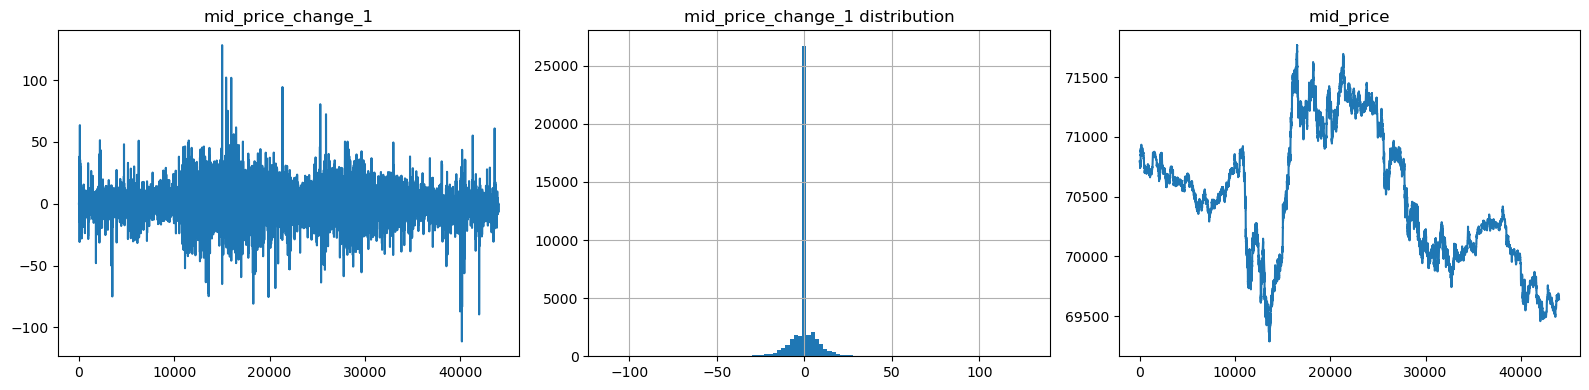

In [3]:
def plot_target_overview(df, target, price):
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))

    df[target].plot(ax=ax[0])
    df[target].hist(ax=ax[1], bins=100)
    df[price].plot(ax=ax[2])

    ax[0].set_title(target)
    ax[1].set_title(f"{target} distribution")
    ax[2].set_title(price)

    plt.tight_layout()
    plt.show()


plot_target_overview(final_dataset, "mid_price_change_1", "mid_price")

- Returns are centred around zero with heavy tails
- Large moves occur but are rare
- Most observations are near zero price often does not move at 1s horizon

In [4]:
move_rate = (final_dataset["mid_price_change_1"] != 0).mean()
move_rate

np.float64(0.42696424918748155)

### Target Exploration

- Target is highly concentrated at zero
- Indicates sparse price movement at this timescale
- Prediction problem is imbalanced and noisy

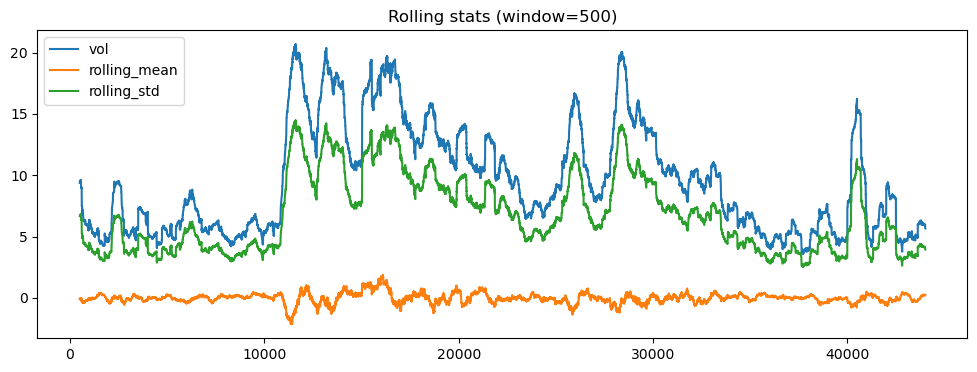

In [5]:
window = 500

fig, ax = plt.subplots(figsize=(12, 4))

series_dict = {
    "vol": final_dataset["log_return_1"].rolling(window).std() * 1e5,
    "rolling_mean": final_dataset["mid_price_change_1"].rolling(window).mean(),
    "rolling_std": final_dataset["mid_price_change_1"].rolling(window).std(),
}

for label, s in series_dict.items():
    s.plot(ax=ax, label=label)

ax.set_title(f"Rolling stats (window={window})")
ax.legend()
plt.show()

- Rolling mean stays close to zero, no drift in returns
- Volatility changes over time, clear clustering
- Variance is not constant
- Volatility clustering suggests regime behaviour
- Model performance may depend on market conditions

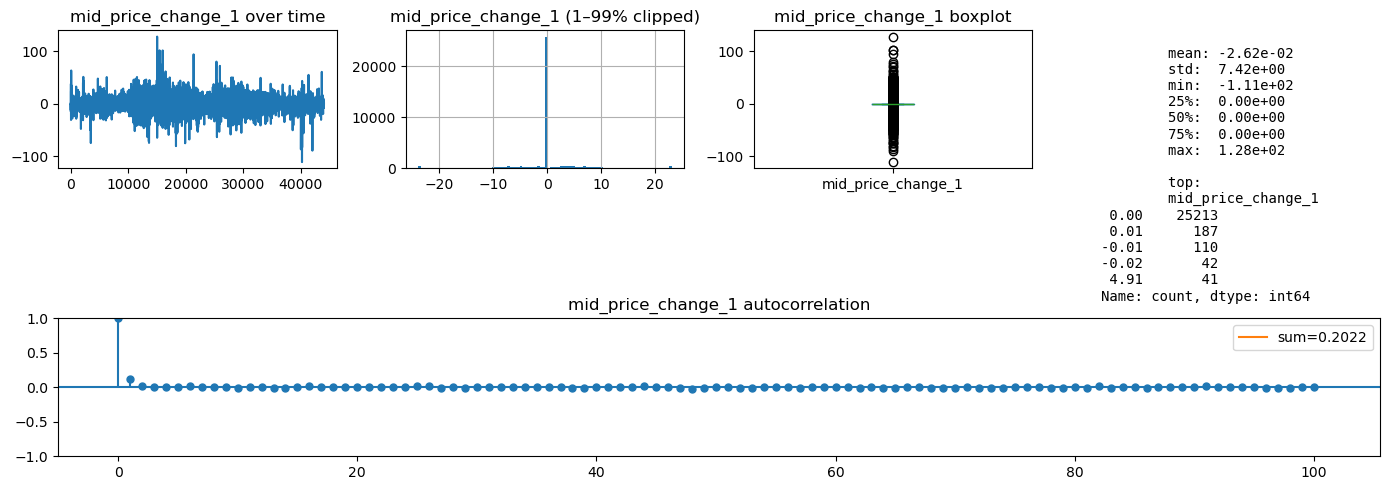

In [6]:
plot_feature_overview(final_dataset, ["mid_price_change_1"], figsize=(14, 5), show=True)

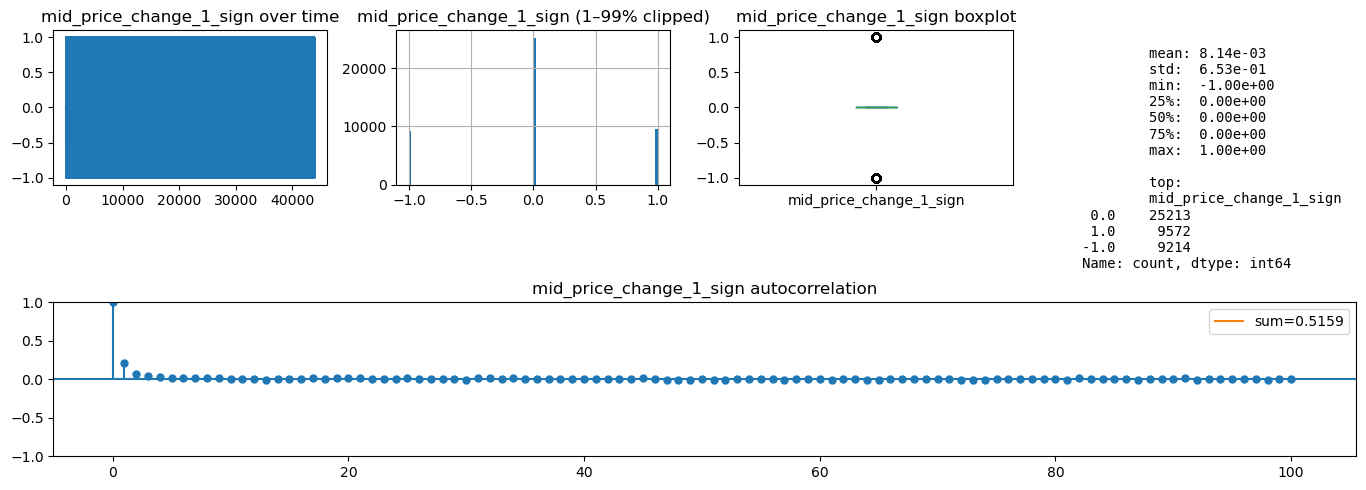

In [7]:
plot_feature_overview(
    final_dataset, ["mid_price_change_1_sign"], figsize=(14, 5), show=True
)

- Returns show near-zero autocorrelation
- Past price changes have little predictive power

- Sign shows small short-lag autocorrelation
- Suggests brief directional persistence over a few steps

### Checking Random Walk

- Test if returns behave like a random walk
- Check if variance scales linearly with time (over horizon even we know its not constant)
- Confirm whether price alone contains signal

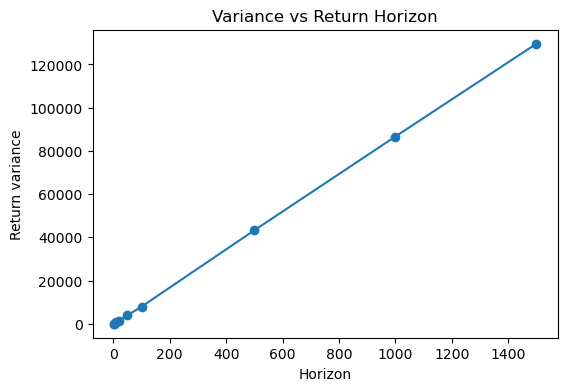

slope ~ 1.0581314650337077


In [8]:
import numpy as np

price = final_dataset["mid_price"].dropna()

hs = np.array([1, 2, 5, 10, 20, 50, 100, 500, 1000, 1500])
vars_ = [price.diff(h).var() for h in hs]
plt.figure(figsize=(6, 4))
plt.plot(hs, vars_, marker="o")
# plt.xscale("log")
plt.xlabel("Horizon")
plt.ylabel("Return variance")
plt.title("Variance vs Return Horizon")

plt.show()
coef = np.polyfit(np.log(hs), np.log(vars_), 1)[0]
print("slope ~", coef)

- Variance increases roughly linearly with horizon
- Does not imply constant volatility, earlier results show clustering

- Price changes alone are close to noise
- Any predictive signal must come from microstructure features

# Class Imbalance

The data is imbalanced, so the model may over-focus on the majority class.

Even though there are more down moves than up moves, the price still trends upward.

This means:
- Up moves are larger
- Down moves are smaller but more frequent

So price increases are driven by a few large upward moves, not many small ones.

Implication:  
Predicting direction alone is not enough — move size matters.

In [9]:
final_dataset["mid_price_change_1_sign"].value_counts(normalize=True)

mid_price_change_1_sign
 0.0    0.573036
 1.0    0.217550
-1.0    0.209414
Name: proportion, dtype: float64

In [10]:
final_dataset.groupby("mid_price_change_1_sign")["mid_price_change_1"].mean()

mid_price_change_1_sign
-1.0   -8.555163
 0.0    0.000000
 1.0    8.114653
Name: mid_price_change_1, dtype: float64

In [11]:
final_dataset["imbalance_1"].mean()

np.float64(0.029238843256626398)

The average imbalance is close to zero.

This means there is no consistent bias in the order book.

So the price increase is likely driven by short periods of strong imbalance, not a constant effect.

# Feature Analysis

Now we analyse the features to see if they contain useful predictive signal.

In [12]:
from microstructure_alpha.features.feature_lists import FEATURE_GROUPS

In [13]:
from pathlib import Path

base_path = Path(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\notebook_figs\\03_figs"
)

for name, cols in FEATURE_GROUPS.items():
    print(name, cols)

    save_dir = base_path / name
    save_dir.mkdir(parents=True, exist_ok=True)

    plot_feature_overview(
        final_dataset,
        cols,
        figsize=(14, 5),
        show=False,
        save_path=save_dir,
    )

lob_features ['lob_bids_price_1', 'lob_bids_price_2', 'lob_bids_price_3', 'lob_bids_price_4', 'lob_bids_price_5', 'lob_bids_price_6', 'lob_bids_price_7', 'lob_bids_price_8', 'lob_bids_price_9', 'lob_bids_price_10', 'lob_bids_volume_1', 'lob_bids_volume_2', 'lob_bids_volume_3', 'lob_bids_volume_4', 'lob_bids_volume_5', 'lob_bids_volume_6', 'lob_bids_volume_7', 'lob_bids_volume_8', 'lob_bids_volume_9', 'lob_bids_volume_10', 'lob_asks_price_1', 'lob_asks_price_2', 'lob_asks_price_3', 'lob_asks_price_4', 'lob_asks_price_5', 'lob_asks_price_6', 'lob_asks_price_7', 'lob_asks_price_8', 'lob_asks_price_9', 'lob_asks_price_10', 'lob_asks_volume_1', 'lob_asks_volume_2', 'lob_asks_volume_3', 'lob_asks_volume_4', 'lob_asks_volume_5', 'lob_asks_volume_6', 'lob_asks_volume_7', 'lob_asks_volume_8', 'lob_asks_volume_9', 'lob_asks_volume_10', 'lob_depth_ratio_2', 'lob_depth_ratio_3', 'lob_depth_ratio_4', 'lob_depth_ratio_5', 'lob_depth_ratio_6', 'lob_depth_ratio_7', 'lob_depth_ratio_8', 'lob_depth_rati

### Feature Summary

**Spread**
- Very small and stable (often at tick size)
- Occasional spikes during high volatility
- No autocorrelation

**Order Book Imbalance**
- Rapidly shifts between buy/sell pressure
- Slight negative mean
- Short-term autocorrelation

**Liquidity**
- Mostly stable with occasional spikes
- Right-skewed distributions (rare large bursts)
- Ratios can produce extreme outliers

**Microprice**
- Tracks price smoothly
- Usually close to mid price
- Spikes align with volatility changes
- No autocorrelation in changes

**Returns & Momentum**
- Centred around zero with small values
- Heavy tails from occasional large moves
- Apparent autocorrelation from overlapping windows

**Volatility**
- Low most of the time with clustered spikes
- Clear autocorrelation (volatility clustering)

**Trade Activity & Volume**
- Irregular bursts of activity
- Heavy-tailed distributions
- Large trades drive spikes more than many small ones

**Trade Flow**
- Covers full range [-1, 1], often extreme

**Trade Dynamics & Lags**
- Changes mostly small with occasional spikes
- Lagged features mirror original behaviour